In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ulrikthygepedersen/online-retail-dataset")

print("Path to dataset files:", path)

100%|██████████| 7.38M/7.38M [00:01<00:00, 4.16MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ulrikthygepedersen/online-retail-dataset/versions/2


In [3]:
import os
import pandas as pd
import numpy as np

# 1. Locate the downloaded file path
dataset_dir = "/root/.cache/kagglehub/datasets/ulrikthygepedersen/online-retail-dataset/versions/2"
csv_filename = "online_retail.csv"  # The file inside the downloaded folder
full_path = os.path.join(dataset_dir, csv_filename)

print(f"Loading data from: {full_path}")
df_raw = pd.read_csv(full_path)

# 2. Initial Data Cleaning
# Drop missing CustomerIDs and filter out returns (negative Quantities / unit prices)
df_clean = df_raw.dropna(subset=['CustomerID']).copy()
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)

# Create Total Price column
df_clean['TotalAmount'] = df_clean['Quantity'] * df_clean['UnitPrice']

# Convert InvoiceDate to datetime
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# Reference date for Recency calculation (one day after the latest transaction)
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

print(f"Cleaned dataset rows: {df_clean.shape[0]}")

# 3. Mass Feature Engineering to hit the 20+ continuous features constraint
print("Engineering 20+ customer-centric continuous behavioral signals...")

# Core RFM Features
customer_df = df_clean.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalAmount', 'sum'),
    TotalQuantity=('Quantity', 'sum'),
    AvgUnitPrice=('UnitPrice', 'mean'),
    MaxSingleSpend=('TotalAmount', 'max'),
    AvgSpendPerInvoice=('TotalAmount', lambda x: x.sum() / df_clean.loc[x.index, 'InvoiceNo'].nunique())
)

# Time-based behavior features
df_clean['Hour'] = df_clean['InvoiceDate'].dt.hour
df_clean['DayOfWeek'] = df_clean['InvoiceDate'].dt.dayofweek # 0=Monday, 6=Sunday
df_clean['Month'] = df_clean['InvoiceDate'].dt.month

time_features = df_clean.groupby('CustomerID').agg(
    MorningPurchases=('Hour', lambda x: sum((x >= 6) & (x < 12))),
    AfternoonPurchases=('Hour', lambda x: sum((x >= 12) & (x < 17))),
    EveningPurchases=('Hour', lambda x: sum((x >= 17) & (x < 24))),
    WeekendPurchases=('DayOfWeek', lambda x: sum(x >= 5)),
    WeekdayPurchases=('DayOfWeek', lambda x: sum(x < 5)),
    Q1Purchases=('Month', lambda x: sum(x.isin([1, 2, 3]))),
    Q2Purchases=('Month', lambda x: sum(x.isin([4, 5, 6]))),
    Q3Purchases=('Month', lambda x: sum(x.isin([7, 8, 9]))),
    Q4Purchases=('Month', lambda x: sum(x.isin([10, 11, 12])))
)

# Product descriptions keywords tracking (Categorical spending footprints)
# Let's see how much they buy items containing common words
keywords = ['HEART', 'VINTAGE', 'CHRISTMAS', 'BAG', 'SIGN', 'BOX', 'BOTTLE']
keyword_dict = {}
for kw in keywords:
    df_clean[f'KW_{kw}'] = df_clean['Description'].str.contains(kw, case=False, na=False).astype(int) * df_clean['Quantity']
    keyword_dict[f'Total_{kw}_Qty'] = (f'KW_{kw}', 'sum')

kw_features = df_clean.groupby('CustomerID').agg(**keyword_dict)

# Combine all engineered data structures together
final_features_df = customer_df.join(time_features).join(kw_features)

print(f"\nTarget Architecture Verified!")
print(f"Total Unique Customers (Rows): {final_features_df.shape[0]}")
print(f"Total Continuous Metrics (Columns): {final_features_df.shape[1]}")
final_features_df.head()

Loading data from: /root/.cache/kagglehub/datasets/ulrikthygepedersen/online-retail-dataset/versions/2/online_retail.csv
Cleaned dataset rows: 397884
Engineering 20+ customer-centric continuous behavioral signals...

Target Architecture Verified!
Total Unique Customers (Rows): 4338
Total Continuous Metrics (Columns): 23


,Recency,Frequency,Monetary,TotalQuantity,AvgUnitPrice,MaxSingleSpend,AvgSpendPerInvoice,MorningPurchases,AfternoonPurchases,EveningPurchases,...,Q2Purchases,Q3Purchases,Q4Purchases,Total_HEART_Qty,Total_VINTAGE_Qty,Total_CHRISTMAS_Qty,Total_BAG_Qty,Total_SIGN_Qty,Total_BOX_Qty,Total_BOTTLE_Qty
CustomerID,,,,,,,,,,,,,,,,,,,,,
12346,326,1,77183.60,74215,1.040000,77183.6,77183.600000,1,0,0,...,0,0,0,0,0,0,0,0,0,0
12347,2,7,4310.00,2458,2.644011,249.6,615.714286,46,136,0,...,42,22,89,226,312,28,154,18,58,0
12348,75,4,1797.24,2341,5.764839,240.0,449.310000,11,3,17,...,5,3,17,288,144,144,0,216,0,0
12349,19,1,1757.55,631,8.289041,300.0,1757.550000,73,0,0,...,0,0,73,121,58,12,8,41,72,0
12350,310,1,334.40,197,3.841176,40.0,334.400000,0,17,0,...,0,0,0,0,12,0,24,36,12,0


In [4]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform your engineered continuous customer data
scaled_features_array = scaler.fit_transform(final_features_df)

# Convert it back to a clean tracking dataframe
scaled_features_df = pd.DataFrame(
    scaled_features_array,
    columns=final_features_df.columns,
    index=final_features_df.index
)

print("Standardization complete! Verification of metrics:")
print(f"Mean of features (Target ~0): {np.allclose(scaled_features_df.mean(), 0, atol=1e-7)}")
print(f"Variance of features (Target ~1): {np.allclose(scaled_features_df.var(ddof=0), 1, atol=1e-7)}")

scaled_features_df.head()

Standardization complete! Verification of metrics:
Mean of features (Target ~0): True
Variance of features (Target ~1): True


,Recency,Frequency,Monetary,TotalQuantity,AvgUnitPrice,MaxSingleSpend,AvgSpendPerInvoice,MorningPurchases,AfternoonPurchases,EveningPurchases,...,Q2Purchases,Q3Purchases,Q4Purchases,Total_HEART_Qty,Total_VINTAGE_Qty,Total_CHRISTMAS_Qty,Total_BAG_Qty,Total_SIGN_Qty,Total_BOX_Qty,Total_BOTTLE_Qty
CustomerID,,,,,,,,,,,,,,,,,,,,,
12346,2.334574,-0.425097,8.358668,14.473038,-0.100205,26.631310,42.734017,-0.358600,-0.378318,-0.161171,...,-0.371985,-0.346445,-0.321335,-0.190076,-0.203753,-0.242789,-0.144339,-0.196746,-0.135293,-0.222417
12347,-0.905340,0.354417,0.250966,0.251058,-0.053315,0.021105,0.109416,0.256767,0.481227,-0.161171,...,0.495281,0.005817,0.466128,0.226734,0.656431,-0.138088,0.033551,-0.164094,0.007929,-0.222417
12348,-0.175360,-0.035340,-0.028596,0.227869,0.037918,0.017785,0.016781,-0.221852,-0.359357,0.429511,...,-0.268739,-0.298409,-0.170921,0.341081,0.193255,0.295672,-0.144339,0.195076,-0.135293,-0.222417
12349,-0.735345,-0.425097,-0.033012,-0.111047,0.111708,0.038538,0.745065,0.625987,-0.378318,-0.161171,...,-0.371985,-0.346445,0.324561,0.033084,-0.043847,-0.197917,-0.135098,-0.122372,0.042500,-0.222417
12350,2.174578,-0.425097,-0.191347,-0.197065,-0.018318,-0.051392,-0.047189,-0.372275,-0.270875,-0.161171,...,-0.371985,-0.346445,-0.321335,-0.190076,-0.170669,-0.242789,-0.116616,-0.131442,-0.105661,-0.222417


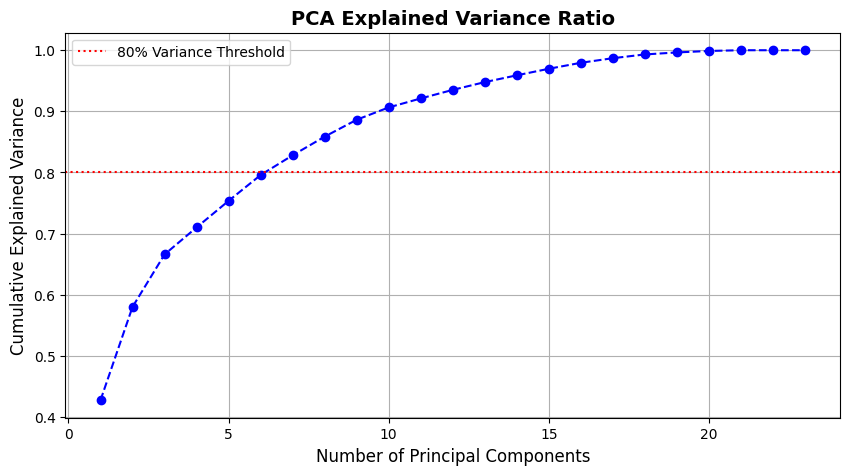

Components 1 to 1 retain 42.73% of the original data's variance.
Components 1 to 2 retain 58.00% of the original data's variance.
Components 1 to 3 retain 66.59% of the original data's variance.
Components 1 to 4 retain 71.01% of the original data's variance.
Components 1 to 5 retain 75.36% of the original data's variance.


In [5]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1. Initialize PCA without restricting components first to see the full variance spectrum
pca_full = PCA()
pca_full.fit(scaled_features_df)

# 2. Calculate cumulative explained variance
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# 3. Plot the Scree Plot to find the "elbow" of information retention
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--', color='b')
plt.title('PCA Explained Variance Ratio', fontsize=14, fontweight='bold')
plt.xlabel('Number of Principal Components', fontsize=12)
plt.ylabel('Cumulative Explained Variance', fontsize=12)
plt.axhline(y=0.80, color='r', linestyle=':', label='80% Variance Threshold')
plt.grid(True)
plt.legend()
plt.show()

# Print out the exact numbers
for i, var in enumerate(cumulative_variance[:5]):
    print(self_print := f"Components 1 to {i+1} retain {var*100:.2f}% of the original data's variance.")

In [6]:
# Apply PCA restricted to 3 components
pca_3d = PCA(n_components=3)
pca_transformed = pca_3d.fit_transform(scaled_features_df)

# Convert to a clean DataFrame for the upcoming clustering phase
pca_df = pd.DataFrame(
    data=pca_transformed,
    columns=['PCA_1', 'PCA_2', 'PCA_3'],
    index=final_features_df.index
)

print("Dimensionality reduction successful!")
print(f"Compressed shape from {scaled_features_df.shape} to {pca_df.shape}")
pca_df.head()

Dimensionality reduction successful!
Compressed shape from (4338, 23) to (4338, 3)


,PCA_1,PCA_2,PCA_3
CustomerID,,,
12346,7.431527,19.325293,47.058625
12347,0.949636,-0.242150,0.120724
12348,-0.230603,0.490913,-0.042928
12349,-0.393702,0.272948,0.502202
12350,-1.181463,0.331630,-0.053489


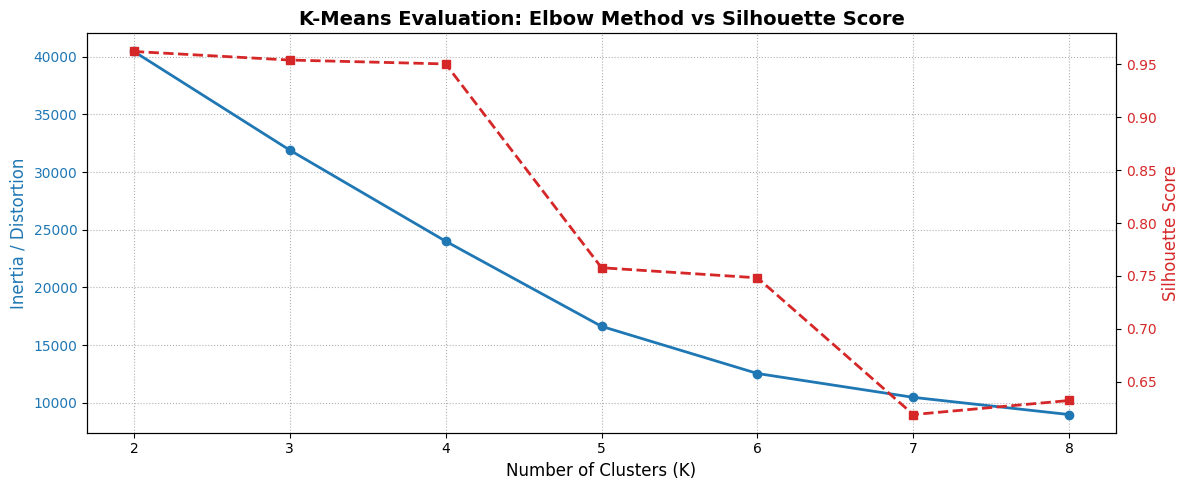

K-Means Validation Table:
K (Clusters)   Inertia        Silhouette Score
2              40452.46       0.9622         
3              31901.14       0.9541         
4              24005.01       0.9504         
5              16626.02       0.7578         
6              12539.31       0.7482         
7              10471.37       0.6190         
8              8979.93        0.6323         


In [7]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Range of clusters to evaluate
k_range = range(2, 9)
inertia_scores = []
silhouette_scores = []

# Loop through each cluster candidate and calculate metrics
for k in k_range:
    # Use random_state=42 for reproducibility as required by standard evaluation
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(pca_df)

    # Store metrics
    inertia_scores.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(pca_df, kmeans.labels_))

# Plotting the Results side-by-side
fig, ax1 = plt.subplots(figsize=(12, 5))

# Plot Inertia (Elbow)
color = 'tab:blue'
ax1.set_xlabel('Number of Clusters (K)', fontsize=12)
ax1.set_ylabel('Inertia / Distortion', color=color, fontsize=12)
ax1.plot(k_range, inertia_scores, marker='o', color=color, linewidth=2, label='Inertia')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle=':')

# Instantiate a second axes that shares the same x-axis for Silhouette Score
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Silhouette Score', color=color, fontsize=12)
ax2.plot(k_range, silhouette_scores, marker='s', color=color, linewidth=2, linestyle='--', label='Silhouette')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('K-Means Evaluation: Elbow Method vs Silhouette Score', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

# Print the formal validation table
print("K-Means Validation Table:")
print(f"{'K (Clusters)':<15}{'Inertia':<15}{'Silhouette Score':<15}")
for i, k in enumerate(k_range):
    print(f"{k:<15}{inertia_scores[i]:<15.2f}{silhouette_scores[i]:<15.4f}")

In [8]:
# Choose your optimal K based on the plot analysis (e.g., 3)
optimal_k = 3

# Fit final K-Means model
kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
final_labels = kmeans_final.fit_transform(pca_df)

# Attach the resulting mathematical clusters back to our original (unscaled) features dataframe
final_features_df['Cluster'] = kmeans_final.labels_

print(f"Successfully grouped {final_features_df.shape[0]} customers into {optimal_k} distinct mathematical clusters!")
print(final_features_df['Cluster'].value_counts())

Successfully grouped 4338 customers into 3 distinct mathematical clusters!
Cluster
0    4317
2      17
1       4
Name: count, dtype: int64


In [9]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# 1. Apply Log Transformation to smooth out massive wholesale outliers
log_features_df = np.log1p(final_features_df.drop(columns=['Cluster'], errors='ignore'))

# 2. Re-scale the log-transformed data
scaler_fixed = StandardScaler()
scaled_fixed_array = scaler_fixed.fit_transform(log_features_df)
scaled_fixed_df = pd.DataFrame(scaled_fixed_array, columns=log_features_df.columns, index=log_features_df.index)

# 3. Re-run PCA (3 Components)
pca_fixed = PCA(n_components=3, random_state=42)
pca_fixed_array = pca_fixed.fit_transform(scaled_fixed_df)
pca_fixed_df = pd.DataFrame(pca_fixed_array, columns=['PCA_1', 'PCA_2', 'PCA_3'], index=log_features_df.index)

# 4. Re-fit K-Means with K=3 on the balanced geometric space
kmeans_fixed = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
final_features_df['Cluster'] = kmeans_fixed.fit_predict(pca_fixed_df)

print("Outlier correction complete! New cluster distribution:")
print(final_features_df['Cluster'].value_counts())

Outlier correction complete! New cluster distribution:
Cluster
1    1832
0    1655
2     851
Name: count, dtype: int64


In [10]:
# Calculate the actual average real-world metrics for each customer segment
cluster_profile = final_features_df.groupby('Cluster').agg(
    CustomerCount=('Recency', 'count'),
    AvgRecency=('Recency', 'mean'),
    AvgFrequency=('Frequency', 'mean'),
    AvgMonetary=('Monetary', 'mean'),
    AvgQuantity=('TotalQuantity', 'mean'),
    AvgUnitPrice=('AvgUnitPrice', 'mean')
).round(2)

print("Executive Corporate Persona Translation Table:\n")
print(cluster_profile)

Executive Corporate Persona Translation Table:

         CustomerCount  AvgRecency  AvgFrequency  AvgMonetary  AvgQuantity  \
Cluster                                                                      
0                 1655       60.09          3.33      1351.46       820.67   
1                 1832      153.41          1.48       345.59       186.18   
2                  851       24.58         12.12      7099.43      4075.81   

         AvgUnitPrice  
Cluster                
0                3.17  
1                6.26  
2                3.15  
